# Imports & Loading the data

In [ ]:
  import torch, random, numpy as np
  torch.manual_seed(42)
  torch.cuda.manual_seed_all(42)
  np.random.seed(42)
  random.seed(42)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

In [2]:
#1 - Imports & paths
from pathlib import Path
import pandas as pd

ROOT = Path('/data0/b2ai-voice/2.0.0')
SPEC = ROOT / 'spectrogram.parquet'
PHEN = ROOT / 'phenotype.tsv'
print(SPEC.exists(), PHEN.exists())


True True


In [3]:
#2 - Load files
import pyarrow.parquet as pq

pheno = pd.read_csv(PHEN, sep='\t')

pf = pq.ParquetFile(SPEC)
parts = []
for i in range(pf.num_row_groups):
    parts.append(pf.read_row_group(i, columns=['participant_id','session_id','task_name','spectrogram']).to_pandas())
spec = pd.concat(parts, ignore_index=True)

print("pheno:", pheno.shape, "spec:", spec.shape)
spec.head(2)


pheno: (442, 1109) spec: (16738, 4)


,participant_id,session_id,task_name,spectrogram
0,004d42e9,07031CC3,Animal-fluency,"[[3.2496545, 0.8633412, 0.29140452, -15.261607..."
1,004d42e9,07031CC3,Cinderella-Story,"[[25.801548, 24.044765, 21.460907, 19.336544, ..."


In [4]:
# #3 - Build Depression label
# Maps “Checked/Unchecked” -> 1/0.

LABEL_COL = "depression_label"
SOURCE_COL = "depression"

pheno[LABEL_COL] = pheno[SOURCE_COL].map({"Checked": 1, "Unchecked": 0})

labels = pheno[["participant_id", LABEL_COL]].dropna().copy()
labels[LABEL_COL] = labels[LABEL_COL].astype(int)

print(labels[LABEL_COL].value_counts())


depression_label
0    390
1     52
Name: count, dtype: int64


In [5]:
# #4 - Merge (Depression)

# Joins spectrograms with labels by participant_id.
data = spec.merge(labels, on="participant_id", how="inner")
print("merged:", data.shape)

# Quick sanity check: label prevalence after merge
print("\nDepression label counts after merge:")
print(data["depression_label"].value_counts())

data[["participant_id", "session_id", "task_name", "depression_label"]].head(3)


merged: (16738, 5)

Depression label counts after merge:
depression_label
0    14871
1     1867
Name: count, dtype: int64


,participant_id,session_id,task_name,depression_label
0,004d42e9,07031CC3,Animal-fluency,1
1,004d42e9,07031CC3,Cinderella-Story,1
2,004d42e9,07031CC3,Diadochokinesis-KA,1


# EDA

In [14]:
#5 - Inspect spectrogram structure (fixed)
import numpy as np

# We now know: 201 frequency bins × 3002 time frames (but stored as object array)
# Let's properly stack one sample and verify

sample = data['spectrogram'].iloc[0]
arr = np.stack(sample)  # Stack the 201 arrays into a proper 2D array
print(f"Single spectrogram shape: {arr.shape}")
print(f"Dtype: {arr.dtype}, Min: {arr.min():.2f}, Max: {arr.max():.2f}")

# Check a few more to confirm consistency
print("\n--- Checking 5 samples ---")
for i in range(5):
    s = data['spectrogram'].iloc[i]
    stacked = np.stack(s)
    print(f"Sample {i}: shape={stacked.shape}")

# Check shape distribution across all data
print("\n--- Shape distribution across dataset ---")
shapes = data['spectrogram'].apply(lambda x: (len(x), len(x[0])))
print(f"Unique shapes: {shapes.nunique()}")
print(shapes.value_counts().head(10))

Single spectrogram shape: (201, 3002)
Dtype: float32, Min: -33.99, Max: 46.01

--- Checking 5 samples ---
Sample 0: shape=(201, 3002)
Sample 1: shape=(201, 12225)
Sample 2: shape=(201, 214)
Sample 3: shape=(201, 197)
Sample 4: shape=(201, 434)

--- Shape distribution across dataset ---
Unique shapes: 2586
spectrogram
(201, 1502)    1274
(201, 607)      321
(201, 3002)     243
(201, 1501)     235
(201, 606)       69
(201, 3001)      40
(201, 255)       39
(201, 218)       39
(201, 187)       38
(201, 196)       38
Name: count, dtype: int64


Time dimension statistics:
  Min: 6
  Max: 16628
  Mean: 934.5
  Median: 597.0
  Std: 1087.7

Percentiles:
  25th: 297
  50th: 597
  75th: 1304
  90th: 1697
  95th: 3002
  99th: 4901


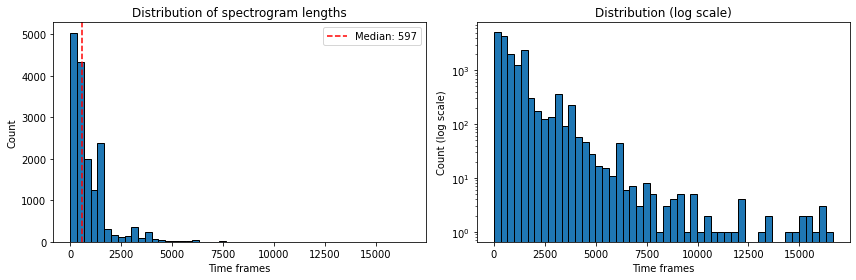


Total samples: 16738


In [15]:
#6 - Analyze time dimension distribution
import numpy as np
import matplotlib.pyplot as plt

# Extract time dimensions
time_dims = data['spectrogram'].apply(lambda x: len(x[0]))

print("Time dimension statistics:")
print(f"  Min: {time_dims.min()}")
print(f"  Max: {time_dims.max()}")
print(f"  Mean: {time_dims.mean():.1f}")
print(f"  Median: {time_dims.median():.1f}")
print(f"  Std: {time_dims.std():.1f}")

# Percentiles to guide truncation/padding decision
percentiles = [25, 50, 75, 90, 95, 99]
print("\nPercentiles:")
for p in percentiles:
    print(f"  {p}th: {np.percentile(time_dims, p):.0f}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(time_dims, bins=50, edgecolor='black')
axes[0].set_xlabel('Time frames')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of spectrogram lengths')
axes[0].axvline(time_dims.median(), color='r', linestyle='--', label=f'Median: {time_dims.median():.0f}')
axes[0].legend()

# Log scale for better visualization of spread
axes[1].hist(time_dims, bins=50, edgecolor='black', log=True)
axes[1].set_xlabel('Time frames')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Distribution (log scale)')

plt.tight_layout()
plt.savefig('time_distribution.png', dpi=150)
plt.show()

print(f"\nTotal samples: {len(time_dims)}")

In [6]:
# #7 - Investigate short recordings and length vs label relationship (Depression)
import numpy as np
import pandas as pd

LABEL_COL = "depression_label"

# Add time dimension to dataframe for analysis
data["time_frames"] = data["spectrogram"].apply(lambda x: len(x[0]))

# Check very short recordings
short_threshold = 100
short_recordings = data[data["time_frames"] < short_threshold]
print(f"Recordings with < {short_threshold} frames: {len(short_recordings)}")
print(f"Their task distribution:\n{short_recordings['task_name'].value_counts()}")
print(f"Their depression label distribution:\n{short_recordings[LABEL_COL].value_counts()}")

# Check if length correlates with depression status (potential bias)
print("\n--- Time frames by depression status ---")
for label in [0, 1]:
    subset = data[data[LABEL_COL] == label]["time_frames"]
    print(f"depression={label}: mean={subset.mean():.1f}, median={subset.median():.1f}, n={len(subset)}")

# Check task distribution overall
print("\n--- Task distribution ---")
print(data["task_name"].value_counts())

# Check task distribution by depression status
print("\n--- Tasks by depression status ---")
print(pd.crosstab(data["task_name"], data[LABEL_COL]))


Recordings with < 100 frames: 184
Their task distribution:
task_name
Respiration-and-cough-Breath-2               20
Respiration-and-cough-Cough-2                20
Respiration-and-cough-FiveBreaths-3          20
Respiration-and-cough-FiveBreaths-4          20
Respiration-and-cough-ThreeQuickBreaths-2    19
Free-speech-2                                12
Free-speech-3                                 8
Story-recall                                  8
Cape-V-sentences-2                            6
Cinderella-Story                              6
Free-speech-1                                 5
Cape-V-sentences-3                            4
Respiration-and-cough-Cough-1                 3
Cape-V-sentences-4                            3
Diadochokinesis-KA                            3
Diadochokinesis-TA                            3
Rainbow-Passage                               3
Loudness                                      2
Respiration-and-cough-Breath-1                2
Cape-V-sentences-6 

# Select HIGH Depression tasks + process raw spectrograms + split + Visualization

In [7]:
# #8 - High-prevalence depression tasks + process raw spectrograms + split (simple)
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split

LABEL_COL = "depression_label"

# Step 1: Keep only selected tasks + minimum length
high_dep_only_tasks = ["Animal-fluency", "Open-response-questions"]
min_time_frames = 100

data_high = data[
    data["task_name"].isin(high_dep_only_tasks) &
    (data["time_frames"] >= min_time_frames)
].copy()

print("Selected tasks:", high_dep_only_tasks)
print("Total samples:", len(data_high))
print("Depression samples:", int(data_high[LABEL_COL].sum()))
print("Non-depression samples:", int((data_high[LABEL_COL] == 0).sum()))
print("Depression ratio:", float(data_high[LABEL_COL].mean()))
print("\nParticipants total:", data_high["participant_id"].nunique())
print("Participants depression:", data_high[data_high[LABEL_COL] == 1]["participant_id"].nunique())
print("Participants non-depression:", data_high[data_high[LABEL_COL] == 0]["participant_id"].nunique())
print("\nSamples per task:")
print(data_high["task_name"].value_counts())

# Step 2: Process RAW spectrograms (pad/crop to fixed time length)
TARGET_SEQ_LEN = 1024

def process_spectrogram_raw(spec_raw, target_len=1024):
    spec = np.stack(spec_raw).astype(np.float32)
    _, time_len = spec.shape

    if time_len < target_len:
        spec = np.pad(spec, ((0, 0), (0, target_len - time_len)), mode="reflect")
    elif time_len > target_len:
        start = (time_len - target_len) // 2
        spec = spec[:, start:start + target_len]

    return spec

X_list = []
for _, row in tqdm(data_high.iterrows(), total=len(data_high), desc="Processing"):
    X_list.append(process_spectrogram_raw(row["spectrogram"], TARGET_SEQ_LEN))

X_raw = np.stack(X_list)
y_raw = data_high[LABEL_COL].values.astype(int)
participants_raw = data_high["participant_id"].values

print("\nProcessed X_raw shape:", X_raw.shape)

# Step 3: Participant-level train/test split
unique_parts = np.unique(participants_raw)
part_labels = np.array([y_raw[participants_raw == p][0] for p in unique_parts])

train_parts, test_parts = train_test_split(
    unique_parts, test_size=0.2, stratify=part_labels, random_state=42
)

train_mask = np.isin(participants_raw, train_parts)
test_mask = np.isin(participants_raw, test_parts)

X_train = X_raw[train_mask]
y_train = y_raw[train_mask]
parts_train = participants_raw[train_mask]

X_test = X_raw[test_mask]
y_test = y_raw[test_mask]
parts_test = participants_raw[test_mask]

print("Train samples:", len(X_train), "Train participants:", len(train_parts), "Train depression rate:", float(y_train.mean()))
print("Test samples:", len(X_test), "Test participants:", len(test_parts), "Test depression rate:", float(y_test.mean()))

assert len(set(train_parts) & set(test_parts)) == 0
print("No participant overlap between train and test.")


Selected tasks: ['Animal-fluency', 'Open-response-questions']
Total samples: 179
Depression samples: 88
Non-depression samples: 91
Depression ratio: 0.49162011173184356

Participants total: 90
Participants depression: 44
Participants non-depression: 46

Samples per task:
task_name
Animal-fluency             95
Open-response-questions    84
Name: count, dtype: int64


Processing: 100%|██████████| 179/179 [00:00<00:00, 997.91it/s]



Processed X_raw shape: (179, 201, 1024)
Train samples: 142 Train participants: 72 Train depression rate: 0.49295774647887325
Test samples: 37 Test participants: 18 Test depression rate: 0.4864864864864865
No participant overlap between train and test.


/home/jupyter-shikshuk/.local/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


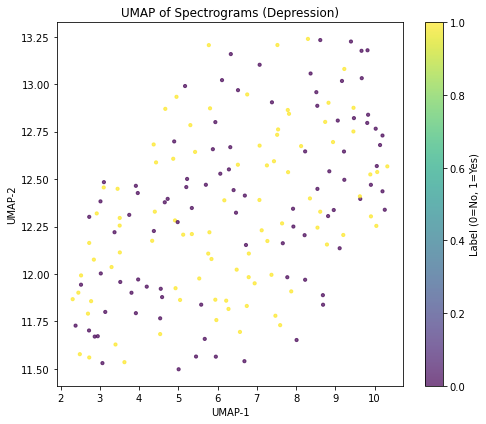

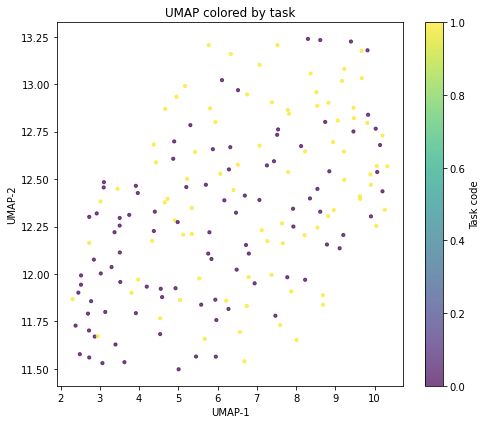

Samples: 179 | Positives: 88 | Positive rate: 0.49162011173184356
Tasks: ['Animal-fluency', 'Open-response-questions']


In [8]:
# UMAP visualization (Depression) using X_raw and participant-level labels
import numpy as np
import matplotlib.pyplot as plt
import umap

LABEL_NAME = "Depression"  # just for plot title

# 1) Flatten spectrograms: (N, 201, 1024) -> (N, 201*1024)
X_flat = X_raw.reshape(X_raw.shape[0], -1)

# 2) Fit UMAP (fast settings; adjust n_neighbors/min_dist if needed)
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)
emb = reducer.fit_transform(X_flat)  # (N, 2)

# 3) Plot by label
plt.figure(figsize=(7, 6))
plt.scatter(emb[:, 0], emb[:, 1], c=y_raw, s=10, alpha=0.7)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title(f"UMAP of Spectrograms ({LABEL_NAME})")
cbar = plt.colorbar()
cbar.set_label("Label (0=No, 1=Yes)")
plt.tight_layout()
plt.show()

# 4) Plot by task (optional, helpful)
task_codes, task_names = pd.factorize(data_high["task_name"].values)
plt.figure(figsize=(7, 6))
plt.scatter(emb[:, 0], emb[:, 1], c=task_codes, s=10, alpha=0.7)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP colored by task")
cbar = plt.colorbar()
cbar.set_label("Task code")
plt.tight_layout()
plt.show()

print("Samples:", len(y_raw), "| Positives:", int(y_raw.sum()), "| Positive rate:", float(y_raw.mean()))
print("Tasks:", list(np.unique(data_high["task_name"])))


# Modelling

In [9]:
# #9 - Audio Spectrogram Transformer (AST) with pre-trained weights (Depression)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from transformers import ASTModel, ASTConfig
from tqdm import tqdm
from scipy.ndimage import zoom

# Resize spectrograms for AST format (expects 128 mel bins)
def resize_spectrogram(spec, target_mel=128, target_time=1024):
    current_mel, current_time = spec.shape
    mel_ratio = target_mel / current_mel
    time_ratio = target_time / current_time
    resized = zoom(spec, (mel_ratio, time_ratio), order=1)
    return resized.astype(np.float32)

# Step 1: Resize
X_train_ast = []
for i in tqdm(range(len(X_train)), desc="Resize train"):
    X_train_ast.append(resize_spectrogram(X_train[i], target_mel=128, target_time=1024))
X_train_ast = np.stack(X_train_ast)

X_test_ast = []
for i in tqdm(range(len(X_test)), desc="Resize test"):
    X_test_ast.append(resize_spectrogram(X_test[i], target_mel=128, target_time=1024))
X_test_ast = np.stack(X_test_ast)

print("Resized shapes:", X_train_ast.shape, X_test_ast.shape)

# Normalize (fit on train)
ast_mean = X_train_ast.mean()
ast_std = X_train_ast.std()
X_train_ast_norm = (X_train_ast - ast_mean) / (ast_std + 1e-8)
X_test_ast_norm = (X_test_ast - ast_mean) / (ast_std + 1e-8)
print("Train normalized mean/std:", float(X_train_ast_norm.mean()), float(X_train_ast_norm.std()))

# Step 2: AST classifier model
class ASTClassifier(nn.Module):
    def __init__(self, num_classes=2, pretrained=True, freeze_base=False):
        super().__init__()

        if pretrained:
            self.ast = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
            hidden_size = self.ast.config.hidden_size
        else:
            config = ASTConfig(
                hidden_size=768,
                num_hidden_layers=12,
                num_attention_heads=12,
                intermediate_size=3072,
                max_length=1024,
                num_mel_bins=128,
            )
            self.ast = ASTModel(config)
            hidden_size = 768

        if freeze_base:
            for param in self.ast.parameters():
                param.requires_grad = False

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)  # (batch, 128, 1024) -> (batch, 1024, 128)
        outputs = self.ast(input_values=x)
        pooled = outputs.pooler_output
        return self.classifier(pooled)

# Step 3: Dataset + loaders
class ASTDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, participants, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.participants = np.array(participants)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            if np.random.random() < 0.5:
                t = np.random.randint(50, 150)
                t0 = np.random.randint(0, max(1, x.shape[1] - t))
                x[:, t0:t0+t] = 0
            if np.random.random() < 0.5:
                f = np.random.randint(10, 30)
                f0 = np.random.randint(0, max(1, x.shape[0] - f))
                x[f0:f0+f, :] = 0

        return {"inputs": x, "labels": self.y[idx], "participant": self.participants[idx]}

train_ds_ast = ASTDataset(X_train_ast_norm, y_train, parts_train, augment=True)
test_ds_ast = ASTDataset(X_test_ast_norm, y_test, parts_test, augment=False)

# Balanced sampler
class_counts = np.bincount(y_train)
weights = 1.0 / class_counts
sample_weights = weights[y_train]
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))

BATCH_SIZE = 8
train_loader_ast = torch.utils.data.DataLoader(
    train_ds_ast, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True
)
test_loader_ast = torch.utils.data.DataLoader(
    test_ds_ast, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)

print("Batches:", len(train_loader_ast), len(test_loader_ast))

# Step 4: Init model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ast = ASTClassifier(num_classes=2, pretrained=True, freeze_base=False).to(device)

total_params = sum(p.numel() for p in model_ast.parameters())
trainable_params = sum(p.numel() for p in model_ast.parameters() if p.requires_grad)
print("Device:", device)
print("Params:", total_params, "Trainable:", trainable_params)

with torch.no_grad():
    batch = next(iter(train_loader_ast))
    out = model_ast(batch["inputs"].to(device))
    print("Forward pass:", batch["inputs"].shape, "->", out.shape)


Resize test: 100%|██████████| 37/37 [00:00<00:00, 464.49it/s]


Resized shapes: (142, 128, 1024) (37, 128, 1024)
Train normalized mean/std: -1.6491230780957267e-06 1.0000005960464478
Batches: 18 5
Device: cuda
Params: 86386178 Trainable: 86386178
Forward pass: torch.Size([8, 128, 1024]) -> torch.Size([8, 2])


In [24]:
# #10 - Train pre-trained AST (Depression)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve
from tqdm import tqdm
import copy
import time

def get_optimizer_groups(model, lr_backbone=5e-6, lr_head=5e-4, weight_decay=0.01):
    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if "classifier" in name:
            head_params.append(param)
        else:
            backbone_params.append(param)
    return [
        {"params": backbone_params, "lr": lr_backbone, "weight_decay": weight_decay},
        {"params": head_params, "lr": lr_head, "weight_decay": weight_decay},
    ]

optimizer = torch.optim.AdamW(
    get_optimizer_groups(model_ast, lr_backbone=5e-6, lr_head=5e-4),
    betas=(0.9, 0.999),
)

NUM_EPOCHS = 50
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

# class weights from y_train
cc = np.bincount(y_train)
cw = (cc.sum() / (2.0 * cc)).astype(np.float32)
class_weights = torch.tensor(cw, dtype=torch.float32).to(device)
criterion = FocalLoss(alpha=class_weights, gamma=2.0)

def evaluate_ast(model, loader, device):
    model.eval()
    all_probs, all_labels, all_parts = [], [], []

    with torch.no_grad():
        for batch in loader:
            inputs = batch["inputs"].to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(batch["labels"].numpy())
            all_parts.extend(batch["participant"])

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_parts = np.array(all_parts)

    # participant-level aggregation (mean over recordings)
    unique_parts = np.unique(all_parts)
    part_probs, part_labels = [], []
    for p in unique_parts:
        m = all_parts == p
        part_probs.append(all_probs[m].mean())
        part_labels.append(all_labels[m][0])

    part_probs = np.array(part_probs)
    part_labels = np.array(part_labels)

    if len(np.unique(part_labels)) > 1:
        part_auc = roc_auc_score(part_labels, part_probs)
        fpr, tpr, thresholds = roc_curve(part_labels, part_probs)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_thresh = thresholds[optimal_idx]
    else:
        part_auc = 0.5
        optimal_thresh = 0.5

    part_preds = (part_probs >= 0.5).astype(int)
    part_preds_opt = (part_probs >= optimal_thresh).astype(int)

    return {
        "part_auc": part_auc,
        "part_f1": f1_score(part_labels, part_preds, zero_division=0),
        "part_f1_opt": f1_score(part_labels, part_preds_opt, zero_division=0),
        "part_recall_opt": recall_score(part_labels, part_preds_opt, zero_division=0),
        "part_prec_opt": precision_score(part_labels, part_preds_opt, zero_division=0),
        "optimal_thresh": float(optimal_thresh),
    }

best_f1 = 0.0
best_auc = 0.0
best_state = None
best_epoch = 0
best_metrics = None
patience = 15
patience_counter = 0

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model_ast.train()
    total_loss = 0.0

    for batch in tqdm(train_loader_ast, desc=f"Epoch {epoch+1}", leave=False):
        inputs = batch["inputs"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model_ast(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ast.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    avg_loss = total_loss / max(1, len(train_loader_ast))

    metrics = evaluate_ast(model_ast, test_loader_ast, device)

    score = 0.4 * metrics["part_auc"] + 0.6 * metrics["part_f1_opt"]
    best_score = 0.4 * best_auc + 0.6 * best_f1

    if score > best_score + 0.01:
        best_f1 = metrics["part_f1_opt"]
        best_auc = metrics["part_auc"]
        best_state = copy.deepcopy(model_ast.state_dict())
        best_epoch = epoch + 1
        best_metrics = metrics.copy()
        patience_counter = 0
    else:
        patience_counter += 1

    lr_backbone = optimizer.param_groups[0]["lr"]
    lr_head = optimizer.param_groups[1]["lr"]

    print(
        f"Epoch {epoch+1:02d} | loss {avg_loss:.4f} | "
        f"AUC {metrics['part_auc']:.3f} | F1@0.5 {metrics['part_f1']:.3f} | "
        f"F1opt {metrics['part_f1_opt']:.3f} | rec {metrics['part_recall_opt']:.3f} | "
        f"prec {metrics['part_prec_opt']:.3f} | thr {metrics['optimal_thresh']:.3f} | "
        f"lr {lr_backbone:.1e}/{lr_head:.1e}"
    )

    if patience_counter >= patience:
        break

elapsed = time.time() - start_time

model_ast.load_state_dict(best_state)

print("Best epoch:", best_epoch)
print("Time (min):", elapsed / 60.0)
print("Best participant AUC:", best_metrics["part_auc"])
print("Best participant F1@0.5:", best_metrics["part_f1"])
print("Best participant F1opt:", best_metrics["part_f1_opt"], "thr:", best_metrics["optimal_thresh"])
print("Best participant recall/precision:", best_metrics["part_recall_opt"], best_metrics["part_prec_opt"])

Epoch 01 | loss 0.2198 | AUC 0.506 | F1@0.5 0.545 | F1opt 0.632 | rec 0.667 | prec 0.600 | thr 0.560 | lr 5.0e-06/5.0e-04


Epoch 02 | loss 0.1555 | AUC 0.605 | F1@0.5 0.609 | F1opt 0.706 | rec 0.667 | prec 0.750 | thr 0.633 | lr 5.0e-06/5.0e-04


Epoch 03 | loss 0.1487 | AUC 0.617 | F1@0.5 0.667 | F1opt 0.706 | rec 0.667 | prec 0.750 | thr 0.541 | lr 5.0e-06/5.0e-04


Epoch 04 | loss 0.1405 | AUC 0.605 | F1@0.5 0.609 | F1opt 0.625 | rec 0.556 | prec 0.714 | thr 0.659 | lr 4.9e-06/4.9e-04


Epoch 05 | loss 0.1245 | AUC 0.580 | F1@0.5 0.429 | F1opt 0.588 | rec 0.556 | prec 0.625 | thr 0.446 | lr 4.9e-06/4.9e-04


...

Epoch 18 | loss 0.0112 | AUC 0.556 | F1@0.5 0.667 | F1opt 0.667 | rec 0.667 | prec 0.667 | thr 0.966 | lr 3.6e-06/3.6e-04


Epoch 19 | loss 0.0269 | AUC 0.494 | F1@0.5 0.429 | F1opt 0.556 | rec 0.556 | prec 0.556 | thr 0.162 | lr 3.5e-06/3.4e-04


Epoch 20 | loss 0.0045 | AUC 0.642 | F1@0.5 0.696 | F1opt 0.706 | rec 0.667 | prec 0.750 | thr 0.936 | lr 3.3e-06/3.3e-04


Epoch 21 | loss 0.0001 | AUC 0.519 | F1@0.5 0.556 | F1opt 0.588 | rec 0.556 | prec 0.625 | thr 0.524 | lr 3.2e-06/3.1e-04


Epoch 22 | loss 0.0000 | AUC 0.494 | F1@0.5 0.375 | F1opt 0.636 | rec 0.778 | prec 0.538 | thr 0.196 | lr 3.0e-06/3.0e-04
Best epoch: 7
Time (min): 4.001483988761902
Best participant AUC: 0.6666666666666666
Best participant F1@0.5: 0.5333333333333333
Best participant F1opt: 0.7058823529411765 thr: 0.46998274326324463
Best participant recall/precision: 0.6666666666666666 0.75


In [25]:
# #11 - 5-Fold Cross-Validation with AST (Depression)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve
from scipy.ndimage import zoom
from tqdm import tqdm
import copy
import time

# helpers
def resize_spectrogram_cv(spec, target_mel=128, target_time=1024):
    current_mel, current_time = spec.shape
    mel_ratio = target_mel / current_mel
    time_ratio = target_time / current_time
    resized = zoom(spec, (mel_ratio, time_ratio), order=1)
    return resized.astype(np.float32)

class ASTDatasetCV(torch.utils.data.Dataset):
    def __init__(self, X, y, participants, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.participants = np.array(participants)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            if np.random.random() < 0.5:
                t = np.random.randint(50, 150)
                t0 = np.random.randint(0, max(1, x.shape[1] - t))
                x[:, t0:t0+t] = 0
            if np.random.random() < 0.5:
                f = np.random.randint(10, 30)
                f0 = np.random.randint(0, max(1, x.shape[0] - f))
                x[f0:f0+f, :] = 0
        return {"inputs": x, "labels": self.y[idx], "participant": self.participants[idx]}

class FocalLossCV(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

def evaluate_fold(model, loader, device):
    model.eval()
    all_probs, all_labels, all_parts = [], [], []
    with torch.no_grad():
        for batch in loader:
            inputs = batch["inputs"].to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(batch["labels"].numpy())
            all_parts.extend(batch["participant"])

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_parts = np.array(all_parts)

    unique_parts = np.unique(all_parts)
    part_probs, part_labels = [], []
    for p in unique_parts:
        m = all_parts == p
        part_probs.append(all_probs[m].mean())
        part_labels.append(all_labels[m][0])

    return np.array(part_probs), np.array(part_labels), unique_parts


# participant-level CV setup
unique_participants = np.unique(participants_raw)
participant_labels = np.array([y_raw[participants_raw == p][0] for p in unique_participants])

print("Participants:", len(unique_participants))
print("Depression positives:", int(participant_labels.sum()), "rate:", float(participant_labels.mean()))

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_results = []
all_oof_probs = np.zeros(len(unique_participants), dtype=np.float32)
all_oof_labels = participant_labels.astype(np.int64).copy()

total_start = time.time()

for fold, (train_idx, val_idx) in enumerate(tqdm(skf.split(unique_participants, participant_labels),
                                                 total=N_FOLDS, desc="CV folds")):
    train_parts_fold = unique_participants[train_idx]
    val_parts_fold = unique_participants[val_idx]

    train_mask = np.isin(participants_raw, train_parts_fold)
    val_mask = np.isin(participants_raw, val_parts_fold)

    X_train_fold = X_raw[train_mask]
    y_train_fold = y_raw[train_mask]
    parts_train_fold = participants_raw[train_mask]

    X_val_fold = X_raw[val_mask]
    y_val_fold = y_raw[val_mask]
    parts_val_fold = participants_raw[val_mask]

    # resize
    X_train_ast_fold = np.stack([resize_spectrogram_cv(x) for x in tqdm(X_train_fold, desc="resize train", leave=False)])
    X_val_ast_fold = np.stack([resize_spectrogram_cv(x) for x in tqdm(X_val_fold, desc="resize val", leave=False)])

    # normalize on fold-train
    m = X_train_ast_fold.mean()
    s = X_train_ast_fold.std()
    X_train_ast_fold = (X_train_ast_fold - m) / (s + 1e-8)
    X_val_ast_fold = (X_val_ast_fold - m) / (s + 1e-8)

    train_ds_fold = ASTDatasetCV(X_train_ast_fold, y_train_fold, parts_train_fold, augment=True)
    val_ds_fold = ASTDatasetCV(X_val_ast_fold, y_val_fold, parts_val_fold, augment=False)

    # balanced sampler
    cc = np.bincount(y_train_fold)
    w = 1.0 / cc
    sample_weights = w[y_train_fold]
    sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))

    train_loader_fold = torch.utils.data.DataLoader(train_ds_fold, batch_size=8, sampler=sampler, num_workers=4, pin_memory=True)
    val_loader_fold = torch.utils.data.DataLoader(val_ds_fold, batch_size=8, shuffle=False, num_workers=4, pin_memory=True)

    # fresh model
    model_fold = ASTClassifier(num_classes=2, pretrained=True, freeze_base=False).to(device)

    backbone_params = [p for n, p in model_fold.named_parameters() if "classifier" not in n]
    head_params = [p for n, p in model_fold.named_parameters() if "classifier" in n]
    optimizer_fold = torch.optim.AdamW([
        {"params": backbone_params, "lr": 5e-6, "weight_decay": 0.01},
        {"params": head_params, "lr": 5e-4, "weight_decay": 0.01},
    ])
    scheduler_fold = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fold, T_max=30, eta_min=1e-7)

    # focal loss weights from fold-train
    cc = np.bincount(y_train_fold)
    cw = (cc.sum() / (2.0 * cc)).astype(np.float32)
    class_weights_fold = torch.tensor(cw, dtype=torch.float32).to(device)
    criterion_fold = FocalLossCV(alpha=class_weights_fold, gamma=2.0)

    best_score = 0.0
    best_state = None
    patience = 10
    patience_counter = 0

    epoch_bar = tqdm(range(30), desc=f"fold {fold+1} epochs", leave=False)
    for epoch in epoch_bar:
        model_fold.train()
        total_loss = 0.0

        for batch in train_loader_fold:
            inputs = batch["inputs"].to(device)
            labels = batch["labels"].to(device)

            optimizer_fold.zero_grad()
            outputs = model_fold(inputs)
            loss = criterion_fold(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_fold.parameters(), 1.0)
            optimizer_fold.step()

            total_loss += loss.item()

        scheduler_fold.step()
        avg_loss = total_loss / max(1, len(train_loader_fold))

        part_probs, part_labels, _ = evaluate_fold(model_fold, val_loader_fold, device)

        if len(np.unique(part_labels)) > 1:
            auc = roc_auc_score(part_labels, part_probs)
            fpr, tpr, thresholds = roc_curve(part_labels, part_probs)
            opt_idx = np.argmax(tpr - fpr)
            opt_thresh = thresholds[opt_idx]
            preds_opt = (part_probs >= opt_thresh).astype(int)
            f1_opt = f1_score(part_labels, preds_opt, zero_division=0)
        else:
            auc, f1_opt = 0.5, 0.0

        epoch_bar.set_postfix({"loss": f"{avg_loss:.4f}", "auc": f"{auc:.3f}", "f1": f"{f1_opt:.3f}"})

        score = 0.4 * auc + 0.6 * f1_opt
        if score > best_score + 0.01:
            best_score = score
            best_state = copy.deepcopy(model_fold.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    model_fold.load_state_dict(best_state)
    part_probs, part_labels, val_pids = evaluate_fold(model_fold, val_loader_fold, device)

    torch.save(model_fold.state_dict(), f"ast_depression_fold{fold+1}.pt")

    # store OOF for these participants
    for i, pid in enumerate(val_pids):
        idx_global = np.where(unique_participants == pid)[0][0]
        all_oof_probs[idx_global] = part_probs[i]

    # fold metrics
    fold_auc = roc_auc_score(part_labels, part_probs)
    fpr, tpr, thresholds = roc_curve(part_labels, part_probs)
    opt_idx = np.argmax(tpr - fpr)
    fold_thresh = thresholds[opt_idx]
    fold_preds = (part_probs >= fold_thresh).astype(int)

    fold_results.append({
        "fold": fold + 1,
        "auc": float(fold_auc),
        "f1_opt": float(f1_score(part_labels, fold_preds, zero_division=0)),
        "recall_opt": float(recall_score(part_labels, fold_preds, zero_division=0)),
        "precision_opt": float(precision_score(part_labels, fold_preds, zero_division=0)),
        "threshold": float(fold_thresh),
    })

    del model_fold, optimizer_fold, train_ds_fold, val_ds_fold
    torch.cuda.empty_cache()

total_time = time.time() - total_start

print("\nFold results:")
for r in fold_results:
    print(r)

aucs = [r["auc"] for r in fold_results]
f1s = [r["f1_opt"] for r in fold_results]
print("Mean AUC:", float(np.mean(aucs)), "Std AUC:", float(np.std(aucs, ddof=1)))
print("Mean F1_opt:", float(np.mean(f1s)), "Std F1_opt:", float(np.std(f1s, ddof=1)))

# OOF metrics
oof_auc = roc_auc_score(all_oof_labels, all_oof_probs)
fpr, tpr, thresholds = roc_curve(all_oof_labels, all_oof_probs)
opt_idx = np.argmax(tpr - fpr)
oof_thresh = thresholds[opt_idx]
oof_preds = (all_oof_probs >= oof_thresh).astype(int)

print("\nOOF AUC:", float(oof_auc))
print("OOF F1_opt:", float(f1_score(all_oof_labels, oof_preds, zero_division=0)), "thr:", float(oof_thresh))
print("OOF recall:", float(recall_score(all_oof_labels, oof_preds, zero_division=0)))
print("OOF precision:", float(precision_score(all_oof_labels, oof_preds, zero_division=0)))
print("Total CV minutes:", total_time / 60.0)


Participants: 90
Depression positives: 44 rate: 0.4888888888888889


resize train:  95%|█████████▌| 133/140 [00:00<00:00, 444.27it/s]
                                                                
resize val:   0%|          | 0/39 [00:00<?, ?it/s]
                                                  
resize train:  92%|█████████▏| 134/145 [00:00<00:00, 445.31it/s]
                                                                
resize val:   0%|          | 0/34 [00:00<?, ?it/s]
                                                  
resize train:  96%|█████████▌| 138/144 [00:00<00:00, 451.33it/s]
                                                                
resize val:   0%|          | 0/35 [00:00<?, ?it/s]
                                                  
resize train:  95%|█████████▌| 138/145 [00:00<00:00, 450.33it/s]
                                                                
resize val:   0%|          | 0/34 [00:00<?, ?it/s]
                                                  
resize train:  99%|█████████▊| 140/142 [00:00<00:00, 456.22it/s]
       


Fold results:
{'fold': 1, 'auc': 0.32098765432098764, 'f1_opt': 0.6666666666666666, 'recall_opt': 0.8888888888888888, 'precision_opt': 0.5333333333333333, 'threshold': 0.3058059513568878}
{'fold': 2, 'auc': 0.617283950617284, 'f1_opt': 0.7058823529411765, 'recall_opt': 0.6666666666666666, 'precision_opt': 0.75, 'threshold': 0.5398372411727905}
{'fold': 3, 'auc': 0.7777777777777778, 'f1_opt': 0.8, 'recall_opt': 0.8888888888888888, 'precision_opt': 0.7272727272727273, 'threshold': 0.4654507040977478}
{'fold': 4, 'auc': 0.962962962962963, 'f1_opt': 0.875, 'recall_opt': 0.7777777777777778, 'precision_opt': 1.0, 'threshold': 0.5361995697021484}
{'fold': 5, 'auc': 0.65, 'f1_opt': 0.7, 'recall_opt': 0.875, 'precision_opt': 0.5833333333333334, 'threshold': 0.4416363835334778}
Mean AUC: 0.6658024691358025 Std AUC: 0.21087619591734977
Mean F1_opt: 0.7495098039215687 Std F1_opt: 0.07683047541890499

OOF AUC: 0.6324110671936759
OOF F1_opt: 0.6990291262135923 thr: 0.4416363835334778
OOF recall: 0.

In [1]:
# CI calculation (ddof=1) - Depression Selected Tasks
from scipy import stats
import numpy as np

aucs = [0.3210, 0.6173, 0.7778, 0.9630, 0.650]
f1s = [0.6667, 0.7059, 0.800, 0.875, 0.700]
recalls = [0.8889, 0.6667, 0.8889, 0.7778, 0.875]
precs = [0.5333, 0.750, 0.7273, 1.000, 0.5833]

n = 5
t_crit = stats.t.ppf(0.975, df=n - 1)

print("Depression Selected Tasks — Per-fold summary (ddof=1)")
for name, arr in [("AUC", aucs), ("F1", f1s), ("Recall", recalls), ("Precision", precs)]:
    m = np.mean(arr)
    sd = np.std(arr, ddof=1)
    se = sd / np.sqrt(n)
    ci_lo = m - t_crit * se
    ci_hi = m + t_crit * se
    print(f"  {name}: {m:.4f} +/- {sd:.4f} [{ci_lo:.4f}, {ci_hi:.4f}]")

Depression Selected Tasks — Per-fold summary (ddof=1)
  AUC: 0.6658 +/- 0.2358 [0.3731, 0.9586]
  F1: 0.7495 +/- 0.0859 [0.6429, 0.8562]
  Recall: 0.8195 +/- 0.0972 [0.6988, 0.9402]
  Precision: 0.7188 +/- 0.1823 [0.4925, 0.9451]
